<a href="https://colab.research.google.com/github/G-Deekshita/BEE-102-Spring-2025-Assignment/blob/main/05_VPlot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problem Statement**

You can imagine when a protein binds to DNA, then that region will be protected by nucleases (a type of enzyme that cleaves DNA). If you are to plot the protected fragments at protein binding sites, it will take a V-form. Your goal is to show this V-formation using the input data.

data

**Example lines from the above file:**

        2	chr1	90919	91937	chr1:91382-91550|carroll_ctcf_mcf7_v45m`2_GTGGCACCAGGTGGCAGCA	16.2951	+	chr1	90838	91006	IH02_00.pairs@15152	168	+
        2	chr1	90919	91937	chr1:91382-91550|carroll_ctcf_mcf7_v45m`2_GTGGCACCAGGTGGCAGCA	16.2951	+	chr1	90846	90998	IH02_04.pairs@4163	152	+
        2	chr1	90919	91937	chr1:91382-91550|carroll_ctcf_mcf7_v45m`2_GTGGCACCAGGTGGCAGCA	16.2951	+	chr1	90851	91000	IH02_04.pairs@4164	149	+
        
From every line of this file, you have to derive three values:

X: Difference between two centers. C1 = center using Column3 and Column4, C2 = center using Column9 and Column10. X-coordinate will be C2 - C1

Y: Column10 - Column9

Z: Counter of Y at X. By default Z for Y at X is Zero.

And example is:

-500 65 10

X: -500, Y: 65, and Z: 10, telling that 500 bases relative to protein bound to DNA has 10 fragments of 65 base pair in size.

You have to plot a heatmap of this.

# **Approach:**
**1.Data Loading and Preprocessing:**


*   Input File: The data is loaded from a BED file (mapped.bed), which contains information about the positions of protein binding sites and fragment locations.
*   DataFrame: We load the BED file into a pandas DataFrame to manipulate and analyze the data.


**2.Compute Centers of Protein-Bound Regions:**


*   C1 (Protein Center): The center of the protein-bound region is calculated as the midpoint between columns 3 and 4 of the BED file (df[2] + df[3] // 2).
*   C2 (Fragment Center): Similarly, the center of the fragment is computed using columns 9 and 10 (df[8] + df[9] // 2).


**3.Compute Offset and Fragment Length:**


*   X (Offset): The offset between the protein center and the fragment center is calculated as df['C2'] - df['C1'].
*   Y (Fragment Length): The length of the fragment is determined by the difference between columns 9 and 8 (df[9] - df[8]).


**4.Count Occurrences of (X, Y) Pairs:**


*   Grouping: We use groupby to group the data by the computed X and Y values.
*   Count: The occurrences of each unique (X, Y) pair are counted using .size(), and the result is reset to a new DataFrame (counts) with the count stored in the 'Z' column.


**5.Get Sorted Unique X and Y Values:**


*   Sorting: We get the sorted list of unique values for both X and Y using sorted().
*   Index Mappings: Mappings from the X and Y values to their indices in the heatmap matrix are created using dictionary comprehensions.


**6.Initialize Heatmap Matrix:**

*   Matrix Setup: We create a zero matrix of size (len(y_vals), len(x_vals)), where each cell represents the count of occurrences for a particular (X, Y) pair.


**7.Populate the Heatmap Matrix:**


*   Filling the Matrix: For each row in the counts DataFrame, the corresponding position in the heatmap matrix is populated using the index mappings (x_index and y_index).


**8.Plotting the Heatmap:**


*   Matplotlib & Seaborn: We use seaborn.heatmap to generate the heatmap.
*   Color Map: The color map (cmap='magma') is applied to the heatmap to visualize the distribution of fragment counts with the 'magma' palette, which transitions from dark to light colors.
*   Axis Adjustments:
     *   The y-axis is inverted using plt.gca().invert_yaxis() to match the original script orientation.
     *   xticks and yticks are adjusted to display a subset of the X and Y values for better readability.
*   Labels and Title: The axes are labeled appropriately, and a title is added to describe the heatmap's contents.


**9.Display:**


*   Finally, plt.show() displays the heatmap with the desired customizations.






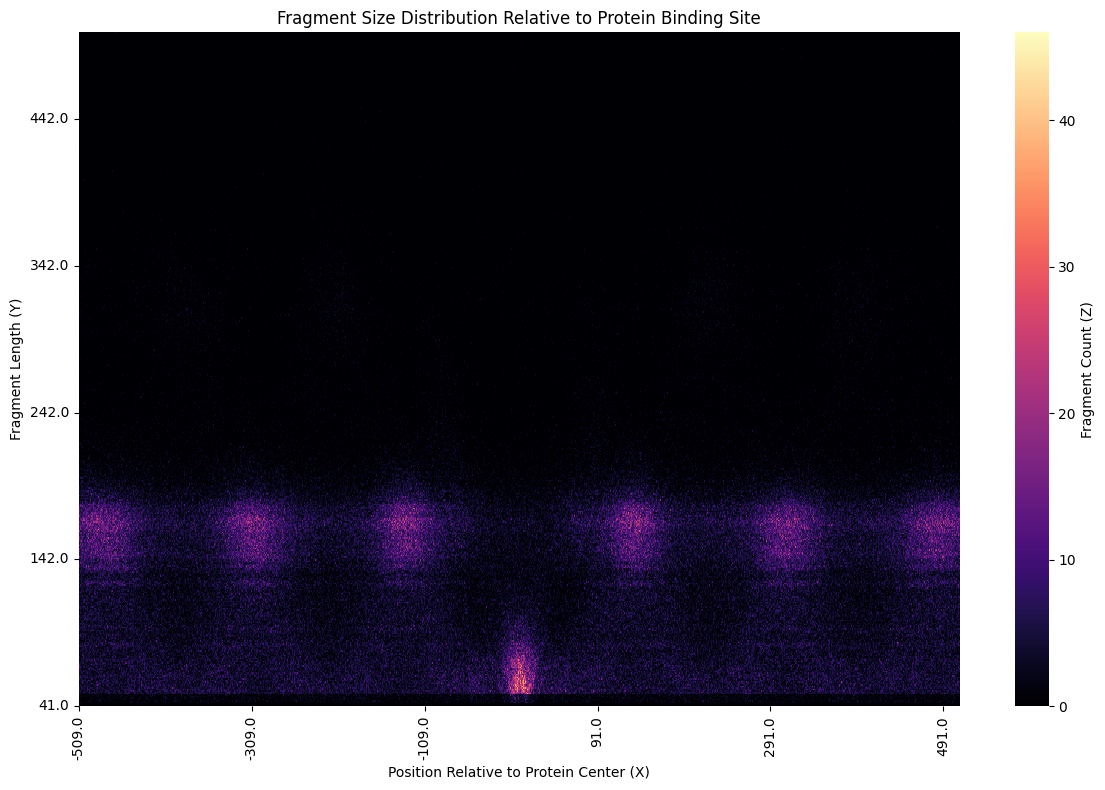

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the extracted BED file
df = pd.read_csv('mapped.bed', sep='\t', header=None)

# Compute center of protein-bound region (col 3 & 4)
df['C1'] = (df[2] + df[3]) // 2

# Compute center of fragment (col 9 & 10)
df['C2'] = (df[8] + df[9]) // 2

# X = offset from protein center, Y = fragment length
df['X'] = df['C2'] - df['C1']
df['Y'] = df[9] - df[8]

# Count occurrences of (X, Y)
counts = df.groupby(['X', 'Y']).size().reset_index(name='Z')

# Get sorted unique X and Y values
x_vals = sorted(counts['X'].unique())
y_vals = sorted(counts['Y'].unique())

# Create index mappings
x_index = {x: i for i, x in enumerate(x_vals)}
y_index = {y: i for i, y in enumerate(y_vals)}

# Initialize empty heatmap matrix
heatmap = np.zeros((len(y_vals), len(x_vals)))

# Fill in the heatmap matrix
for _, row in counts.iterrows():
    x = row['X']
    y = row['Y']
    z = row['Z']
    heatmap[y_index[y], x_index[x]] = z

# Plotting
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap, cmap='magma', cbar_kws={'label': 'Fragment Count (Z)'})

plt.gca().invert_yaxis()  # To match the original script orientation
plt.xticks(np.arange(len(x_vals))[::200], x_vals[::200])
plt.yticks(np.arange(len(y_vals))[::100], y_vals[::100])
plt.title('Fragment Size Distribution Relative to Protein Binding Site')
plt.xlabel('Position Relative to Protein Center (X)')
plt.ylabel('Fragment Length (Y)')
plt.tight_layout()
plt.show()
